In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import random
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score
import optuna

# Pandas setting to display more dataset rows and columns
pd.set_option('display.max_rows', 150)
pd.set_option('display.max_columns', 500)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.float_format', lambda x: '%.5f' % x)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/tabular-playground-series-nov-2021/sample_submission.csv
/kaggle/input/tabular-playground-series-nov-2021/train.csv
/kaggle/input/tabular-playground-series-nov-2021/test.csv


# **Data import**

In [2]:
train = pd.read_csv("/kaggle/input/tabular-playground-series-nov-2021/train.csv", low_memory=False)#, nrows=10000)
test = pd.read_csv("/kaggle/input/tabular-playground-series-nov-2021/test.csv", low_memory=False)#, nrows=10000)
train.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600000 entries, 0 to 599999
Columns: 102 entries, id to target
dtypes: float64(100), int64(2)
memory usage: 466.9 MB


In [3]:
test.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 540000 entries, 0 to 539999
Columns: 101 entries, id to f99
dtypes: float64(100), int64(1)
memory usage: 416.1 MB


# **EDA**

In [4]:
# Colors to be used for plots
colors = ["lightcoral", "sandybrown", "darkorange", "mediumseagreen",
          "lightseagreen", "cornflowerblue", "mediumpurple", "palevioletred",
          "lightskyblue", "sandybrown", "yellowgreen", "indianred",
          "lightsteelblue", "mediumorchid", "deepskyblue"]

In [5]:
train.head()

,id,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16,f17,f18,f19,f20,f21,f22,f23,f24,f25,f26,f27,f28,f29,f30,f31,f32,f33,f34,f35,f36,f37,f38,f39,f40,f41,f42,f43,f44,f45,f46,f47,f48,f49,f50,f51,f52,f53,f54,f55,f56,f57,f58,f59,f60,f61,f62,f63,f64,f65,f66,f67,f68,f69,f70,f71,f72,f73,f74,f75,f76,f77,f78,f79,f80,f81,f82,f83,f84,f85,f86,f87,f88,f89,f90,f91,f92,f93,f94,f95,f96,f97,f98,f99,target
0,0,0.10664,3.59437,132.80400,3.18428,0.08197,1.18859,3.73238,2.26627,2.09959,0.01233,1.60719,-0.31806,0.56014,2.80688,1.35114,2.53593,0.19753,0.67649,1.98979,-3.84245,0.03738,0.23032,3.33055,0.00940,0.14474,3.05131,1.30362,0.03322,-0.01828,2.74821,-0.00929,-0.03627,-0.04987,0.01948,3.89846,11.28630,1.13802,3.36688,4.94446,-0.10577,2.11345,3.45223,0.78943,1.11321,1.49157,2.44037,0.04182,3.35537,0.05369,1.70127,0.90883,0.09490,0.03022,0.59702,4.44341,1.58649,-0.06869,-0.10827,0.06104,0.04610,0.01711,-0.02755,0.01948,-0.04883,0.05075,3.72930,5.01744,4.18688,0.06334,0.12104,1.37175,4.01745,0.16761,0.03975,2.04236,-0.01661,0.10768,3.50725,0.01366,-0.09702,5.39607,0.24446,3.49184,0.11309,-0.01547,4.20879,4.10656,0.03723,-0.11881,0.06709,0.01074,1.09862,0.01333,-0.01172,0.05276,0.06540,4.21125,1.97877,0.08597,0.24050,0
1,1,0.12502,1.67336,76.53360,3.37825,0.09940,5.09366,1.27562,-0.47132,4.54594,0.03771,0.33175,0.32509,0.06204,2.26215,4.33943,-0.22500,0.23359,3.38128,1.90299,0.06787,-0.05127,0.00613,2.60444,0.10344,0.06764,4.75362,1.85552,-0.18183,0.00836,3.16634,0.01185,0.02229,0.06932,0.11711,0.31528,24.48070,1.67227,-0.40907,4.95475,0.09236,2.60318,1.95469,0.00590,3.28934,2.56453,0.81771,0.02600,4.61749,1.57554,0.06611,0.68163,0.02525,0.18350,0.11004,2.74612,0.83559,0.18820,4.96064,0.13609,-0.00849,-0.01526,-0.01084,0.06458,0.10255,0.09361,0.96409,0.63042,4.30734,0.09129,-0.03636,3.61767,3.10324,0.00066,0.05130,1.92462,0.12329,-0.02267,1.54812,-0.01040,0.05833,3.66131,-0.11839,2.35739,-0.00911,0.17870,4.09735,3.53289,0.00524,0.12138,0.10997,0.13584,3.46017,0.01705,0.12486,0.15406,0.60685,-0.26793,2.57786,-0.02088,0.02472,0
2,2,0.03633,1.49747,233.54600,2.19435,0.02691,3.12694,5.05687,3.84946,1.80187,0.05699,0.32868,2.96881,0.10524,2.06949,5.30986,1.35479,-0.26202,1.37908,1.48091,0.02054,-0.00881,0.10935,1.68365,0.03818,0.12372,1.11248,3.57166,0.12060,0.08207,2.23352,0.00227,0.04518,0.01440,0.01160,-0.50285,33.73820,1.41750,1.07135,3.22296,2.12203,3.08216,0.63755,-0.00682,-0.39094,17.34570,3.70043,-0.03360,1.57824,0.05198,-0.00200,2.69096,0.01837,-0.03047,0.11141,2.18747,-0.32500,-0.01994,3.45503,0.06811,-0.00981,-0.01063,0.02757,-0.00712,-0.04891,-0.00257,1.86509,2.40417,0.41174,0.05775,0.52517,2.16879,0.82830,0.08985,0.09374,4.94901,-0.01098,0.07667,0.26678,0.03869,0.38273,3.84760,-0.12148,3.74084,0.14710,-0.01657,0.61465,2.12584,0.07883,0.97981,0.02676,0.11731,4.88300,0.08522,0.03240,0.11609,-0.00169,-0.52007,2.14112,0.12446,0.14821,0
3,3,-0.01408,0.24600,779.96700,1.89064,0.00695,1.53112,2.69800,4.51733,4.50332,0.12349,1.00268,4.86960,0.05841,2.49785,1.23843,2.34836,0.17547,1.60889,2.02881,0.04209,0.00514,0.07651,1.65122,0.11181,0.12164,0.58912,4.23692,-0.03284,0.05817,0.71293,0.09747,0.07274,0.00032,0.06336,4.06382,25.38240,0.57657,2.02621,2.96843,1.08567,1.71088,1.37182,0.03463,0.72261,71.44850,3.03458,0.09224,3.45310,0.04483,0.02719,4.08285,0.04696,0.06369,0.02923,0.67202,0.18531,0.16428,3.80456,0.06231,-0.02141,0.00947,0.11088,0.02684,2.93116,0.06811,-0.49519,1.34528,2.24275,0.03561,-0.13927,4.74243,3.29274,0.11788,0.06561,0.55671,-0.05803,0.07050,1.10125,0.06856,0.16293,4.07018,-0.00884,3.89678,0.91374,-0.16320,3.07485,4.35678,-0.04889,4.91799,0.06993,-0.01535,3.47439,-0.01710,-0.00810,0.06201,0.04119,0.51166,1.96860,0.04002,0.04487,0
4,4,-0.00326,3.71542,156.12800,2.14772,0.01828,2.09859,4.15492,-0.03824,3.37145,0.03417,0.71148,0.76999,0.05755,0.95726,3.71145,5.46435,0.28710,2.61695,1.38403,0.07488,-0.01054,0.10912,2.27602,0.00802,0.04524,4.35954,5.07562,-0.00938,0.52897,4.05335,0.02000,0.10683,0.05131,0.04594,3.40246,15.56150,

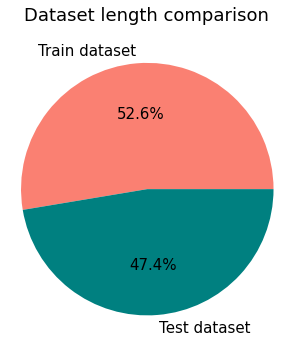

In [6]:
fig, ax = plt.subplots(figsize=(5, 6))
pie = ax.pie([len(train), len(test)],
             labels=["Train dataset", "Test dataset"],
             colors=["salmon", "teal"],
             textprops={"fontsize": 15},
             autopct='%1.1f%%')
ax.axis("equal")
ax.set_title("Dataset length comparison", fontsize=18)
fig.set_facecolor('white')
plt.show();

In [7]:
train.describe()

,id,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16,f17,f18,f19,f20,f21,f22,f23,f24,f25,f26,f27,f28,f29,f30,f31,f32,f33,f34,f35,f36,f37,f38,f39,f40,f41,f42,f43,f44,f45,f46,f47,f48,f49,f50,f51,f52,f53,f54,f55,f56,f57,f58,f59,f60,f61,f62,f63,f64,f65,f66,f67,f68,f69,f70,f71,f72,f73,f74,f75,f76,f77,f78,f79,f80,f81,f82,f83,f84,f85,f86,f87,f88,f89,f90,f91,f92,f93,f94,f95,f96,f97,f98,f99,target
count,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000,600000.00000
mean,299999.50000,0.30651,2.49759,306.64454,2.64790,0.17785,2.55683,2.69965,2.57159,2.53827,0.13437,2.57999,2.75927,0.12896,2.47724,2.66286,2.63104,0.36248,2.48308,2.47132,0.10810,0.09378,0.06216,2.55978,0.09706,0.14105,2.58009,2.45910,0.05795,0.21679,2.47134,0.12564,0.10780,0.17043,0.05478,2.46341,55.69885,1.76951,2.59508,2.41093,0.59350,2.64609,2.58262,0.10900,2.50006,3.22737,2.59589,0.06175,2.53715,0.08500,0.24499,2.55896,0.09315,0.31488,0.10927,2.45522,2.57175,0.27002,2.60428,0.09961,0.08734,0.08886,0.14426,0.12430,0.34020,0.08639,2.51344,2.57700,2.52232,0.13447,0.18936,2.49492,2.63267,0.12983,0.05081,2.55127,0.17406,0.23182,2.42026,0.10177,0.34987,2.55017,0.90298,2.59803,0.16277,0.50198,2.58727,2.65346,0.26520,0.33576,0.05687,0.07125,2.44447,0.15526,0.05941,0.14493,0.10642,2.54785,2.59016,0.15888,0.12305,0.50601
std,173205.22509,0.52245,1.55402,551.74389,1.54453,0.41749,1.56253,1.56400,1.54936,1.53299,0.42189,1.60439,1.54522,0.21086,1.51769,1.48197,1.53107,1.34635,1.57746,1.54157,0.39531,0.30894,0.05480,1.55650,0.33359,0.34238,1.60957,1.56789,0.11413,0.33932,1.52433,0.29656,0.41229,0.44062,0.10966,1.56657,130.13289,1.78571,1.56251,1.57208,0.95189,1.56793,1.53706,0.35605,1.57515,5.41426,1.55977,0.36543,1.50202,0.29298,0.62262,1.61102,0.34160,0.57966,0.20164,1.53355,1.48522,0.85235,1.53212,0.59011,0.43244,0.15199,0.37796,0.41404,0.62301,0.21601,1.51634,1.56382,1.53232,0.39900,0.74455,1.57523,1.54187,0.30831,0.04914,1.51361,0.64181,1.20628,1.55789,0.24573,0.59683,1.57679,1.33561,1.54278,0.29583,2.36429,1.56417,1.54694,0.56223,0.99360,0.12861,0.11265,1.54251,0.54840,0.11943,0.46201,0.20913,1.55843,1.52509,0.43619,0.26490,0.49996
min,0.00000,-3.79745,-1.22396,-1842.53000,-1.36856,-3.20621,-1.16977,-1.05931,-1.28197,-1.24202,-2.57784,-1.30973,-1.45157,-0.67814,-1.29516,-1.21389,-1.45054,-18.16960,-1.38772,-1.22102,-5.33411,-2.85855,-0.15152,-1.20107,-2.72166,-2.64525,-1.38043,-1.14726,-2.28105,-4.59670,-1.22565,-2.02571,-3.27300,-1.95452,-3.31842,-1.51772,-397.00400,-2.88894,-1.21037,-1.18105,-2.61123,-1.09884,-1.63780,-3.25592,-1.24641,-42.44320,-1.21715,-9.06786,-1.35130,-3.47747,-2.24733,-1.48940,-5.32141,-2.21395,-0.65337,-1.32253,-1.13158,-3.24735,-1.23706,-14.03220,-6.87636,-1.73652,-1.32657,-2.55308,-5.15313,-3.49895,-1.2

In [8]:
features = [x for x in train.columns if x[0]=="f"]

df = pd.concat([train[features], test[features]], axis=0)
df.reset_index(inplace=True, drop=True)

unique_values = df[features].nunique() < 30
cat_features = unique_values[unique_values==True].index
unique_values = df[features].nunique() >= 30
num_features = unique_values[unique_values==True].index

print(f"There are {len(cat_features)} categorical features: {cat_features}")
print(f"There are {len(num_features)} continuous features: {num_features}")

There are 0 categorical features: Index([], dtype='object')
There are 100 continuous features: Index(['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10',
       'f11', 'f12', 'f13', 'f14', 'f15', 'f16', 'f17', 'f18', 'f19', 'f20',
       'f21', 'f22', 'f23', 'f24', 'f25', 'f26', 'f27', 'f28', 'f29', 'f30',
       'f31', 'f32', 'f33', 'f34', 'f35', 'f36', 'f37', 'f38', 'f39', 'f40',
       'f41', 'f42', 'f43', 'f44', 'f45', 'f46', 'f47', 'f48', 'f49', 'f50',
       'f51', 'f52', 'f53', 'f54', 'f55', 'f56', 'f57', 'f58', 'f59', 'f60',
       'f61', 'f62', 'f63', 'f64', 'f65', 'f66', 'f67', 'f68', 'f69', 'f70',
       'f71', 'f72', 'f73', 'f74', 'f75', 'f76', 'f77', 'f78', 'f79', 'f80',
       'f81', 'f82', 'f83', 'f84', 'f85', 'f86', 'f87', 'f88', 'f89', 'f90',
       'f91', 'f92', 'f93', 'f94', 'f95', 'f96', 'f97', 'f98', 'f99'],
      dtype='object')


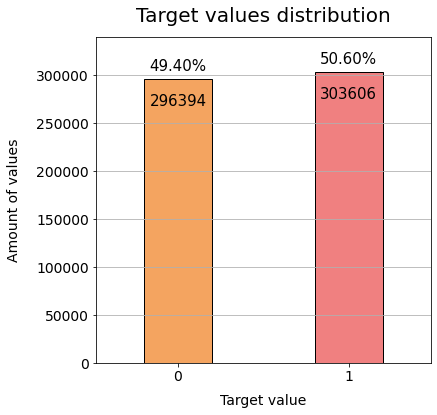

In [9]:
fig, ax = plt.subplots(figsize=(6, 6))

bars = ax.bar(train["target"].value_counts().index,
              train["target"].value_counts().values,
              color=colors,
              edgecolor="black",
              width=0.4)
ax.set_title("Target values distribution", fontsize=20, pad=15)
ax.set_ylabel("Amount of values", fontsize=14, labelpad=15)
ax.set_xlabel("Target value", fontsize=14, labelpad=10)
ax.set_xticks(train["target"].value_counts().index)
ax.tick_params(axis="both", labelsize=14)
ax.bar_label(bars, [f"{x:2.2f}%" for x in train["target"].value_counts().values/(len(train)/100)],
                 padding=5, fontsize=15)
ax.bar_label(bars, [f"{x:2d}" for x in train["target"].value_counts().values],
                 padding=-30, fontsize=15)
ax.margins(0.2, 0.12)
ax.grid(axis="y")

plt.show();

The target value classes are balanced which is good.

In [10]:
train.isna().sum().sum(), test.isna().sum().sum()

(0, 0)

There are no missing values in the both datasets.

Let's check feature values distribution in the both datasets.

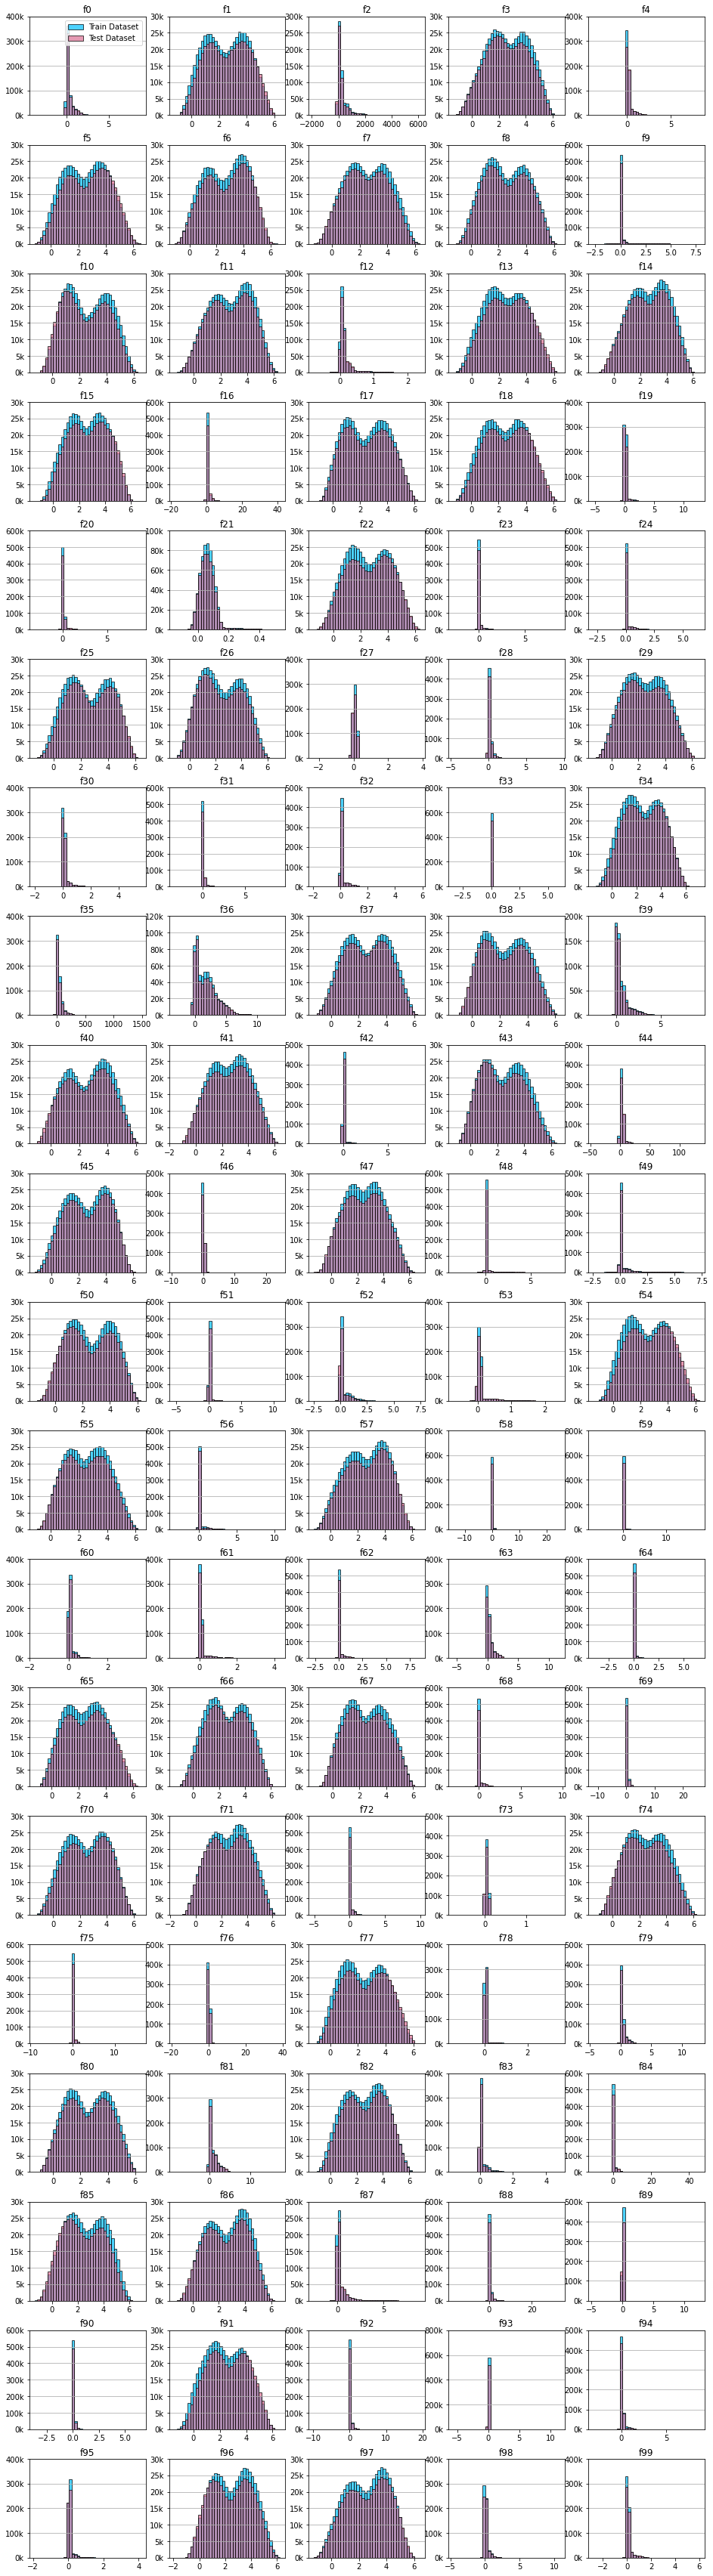

In [11]:
df = pd.concat([train[num_features], test[num_features]], axis=0)
columns = df.columns.values

cols = 5
rows = len(columns) // cols + 1

fig, axs = plt.subplots(ncols=cols, nrows=rows, figsize=(16,65), sharex=False)

plt.subplots_adjust(hspace = 0.3)
i=0

for r in np.arange(0, rows, 1):
    for c in np.arange(0, cols, 1):
        if i >= len(columns):
            axs[r, c].set_visible(False)
        else:
            hist1 = axs[r, c].hist(train[columns[i]].values,
                                   range=(df[columns[i]].min(),
                                          df[columns[i]].max()),
                                   bins=40,
                                   color="deepskyblue",
                                   edgecolor="black",
                                   alpha=0.7,
                                   label="Train Dataset")
            hist2 = axs[r, c].hist(test[columns[i]].values,
                                   range=(df[columns[i]].min(),
                                          df[columns[i]].max()),
                                   bins=40,
                                   color="palevioletred",
                                   edgecolor="black",
                                   alpha=0.7,
                                   label="Test Dataset")
            axs[r, c].set_title(columns[i], fontsize=12, pad=5)
            axs[r, c].set_yticks(axs[r, c].get_yticks())
            axs[r, c].set_yticklabels([str(int(i/1000))+"k" for i in axs[r, c].get_yticks()])
            axs[r, c].tick_params(axis="y", labelsize=10)
            axs[r, c].tick_params(axis="x", labelsize=10)
            axs[r, c].grid(axis="y")
            if i == 0:
                axs[r, c].legend(fontsize=10)
                                  
        i+=1
#plt.suptitle("Numerical feature values distribution in both datasets", y=0.99)
plt.show();

Some features look like categorical ones. Maybe it's worth to try to transform them into bins.

As you can see, the datasets are well balanced. So target distribution should probably be the same for test predictions.

In [12]:
print("Numerical features with the least amount of unique values:")
train[num_features].nunique().sort_values().head(5)

Numerical features with the least amount of unique values:


f14    390511
f11    395261
f55    397458
f3     398271
f15    399560
dtype: int64

Let's look at feature correlation.

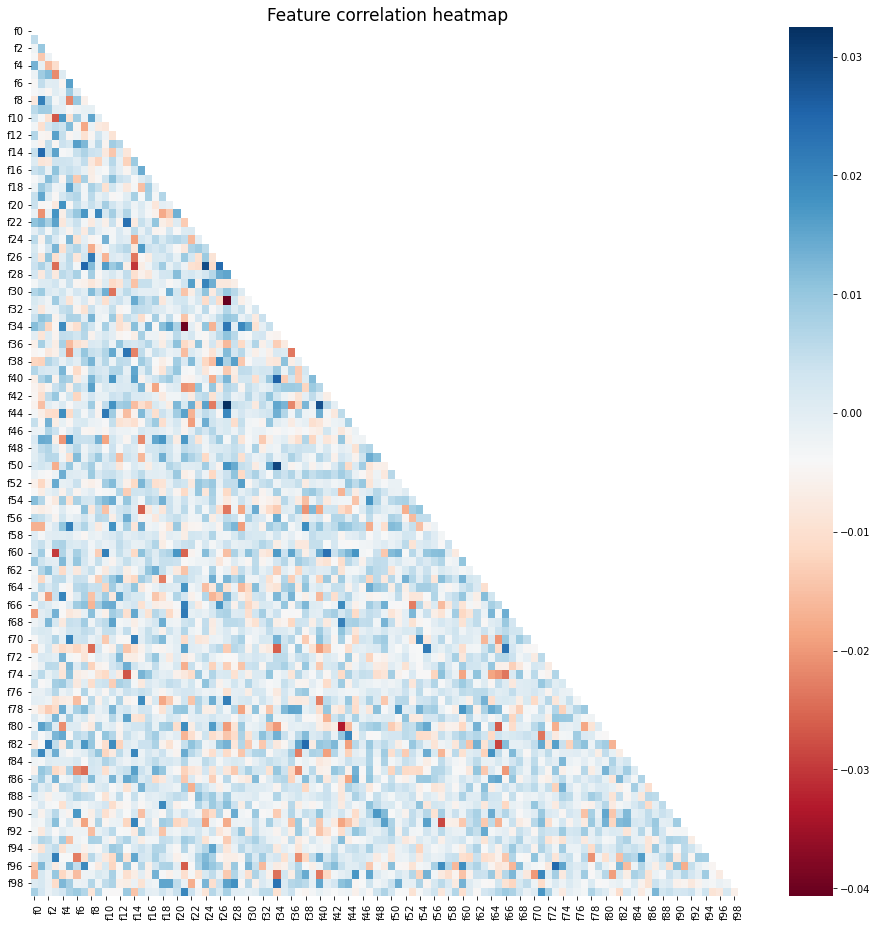

In [13]:
# Plot dataframe
df = train[features].corr().round(5)

# Mask to hide upper-right part of plot as it is a duplicate
mask = np.zeros_like(df)
mask[np.triu_indices_from(mask)] = True

# Making a plot
plt.figure(figsize=(16,16))
ax = sns.heatmap(df, annot=False, mask=mask, cmap="RdBu", annot_kws={"weight": "bold", "fontsize":13})
ax.set_title("Feature correlation heatmap", fontsize=17)
plt.setp(ax.get_xticklabels(), rotation=90, ha="right",
         rotation_mode="anchor", weight="normal")
plt.setp(ax.get_yticklabels(), weight="normal",
         rotation_mode="anchor", rotation=0, ha="right")
plt.show();

There is very weak linear correlation between the features.

# **Data preprocessing**

In [14]:
# Scaling all values
s_scaler = StandardScaler()
for col in features:
    train[col] = s_scaler.fit_transform(np.array(train[col]).reshape(-1,1))
    test[col] = s_scaler.transform(np.array(test[col]).reshape(-1,1))

In [15]:
X = train[features].copy()
X_test = test[features].copy()
y = train["target"]

# **Hyperparameters optimization**

Hyperparameters used in this notebook were optimized using Optuna. The code used or that is shown below. They are commented in order to save runtime as optimization has been already done.

In [16]:
# def train_model_optuna(trial, X_train, X_valid, y_train, y_valid):
#     """
#     A function to train a model using different hyperparamerters combinations provided by Optuna. 
#     Loss of validation data predictions is returned to estimate hyperparameters effectiveness.
#     """

#     #A set of hyperparameters to optimize by optuna
#     xgb_params = {
#                  "objective": trial.suggest_categorical('objective', ["binary:logistic"]),
#                  "use_label_encoder": trial.suggest_categorical('use_label_encoder', [False]),
#                  "n_estimators": trial.suggest_categorical('n_estimators', [40000]),
#                  "learning_rate": trial.suggest_loguniform('learning_rate', 0.15, 1.0),
#                  "subsample": trial.suggest_float('subsample', 0.1, 1, step=0.01),
#                  "colsample_bytree": trial.suggest_float('colsample_bytree', 0.05, 1, step=0.01),
#                  "max_depth": trial.suggest_int("max_depth", 1, 8),
#                  "booster": trial.suggest_categorical('booster', ["gbtree"]),
#                  "gamma": trial.suggest_float('gamma', 0, 100, step=0.1),
#                  "tree_method": trial.suggest_categorical('tree_method', ["gpu_hist"]),
#                  "reg_lambda": trial.suggest_loguniform('reg_lambda', 0.1, 100),
#                  "reg_alpha": trial.suggest_loguniform('reg_alpha', 0.1, 100),
#                  "random_state": trial.suggest_categorical('random_state', [42]),
#                  "n_jobs": trial.suggest_categorical('n_jobs', [4]),
#                  "min_child_weight": trial.suggest_categorical("min_child_weight", [256]),
#                     }



#     # Model loading and training
#     model = XGBClassifier(**xgb_params)
#     model.fit(X_train, y_train,
#               eval_set=[(X_train, y_train), (X_valid, y_valid)],
#               eval_metric="auc",
#               early_stopping_rounds=100,
#               verbose=False)
    
#     print(f"Number of boosting rounds: {model.best_iteration}")
#     oof = model.predict_proba(X_valid)[:, 1]
    
#     return roc_auc_score(y_valid, oof)

In [17]:
# %%time
# # Splitting data into train and valid folds using target bins for stratification
# X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# # Setting optuna verbosity to show only warning messages
# # If the line is uncommeted each iteration results will be shown
# # optuna.logging.set_verbosity(optuna.logging.WARNING)

# time_limit = 3600 * 4

# study = optuna.create_study(direction='maximize')
# study.optimize(lambda trial: train_model_optuna(trial, X_train, X_valid,
#                                                     y_train, y_valid),
# #                n_trials = 2
#                timeout=time_limit
#               )

# # Showing optimization results
# print('Number of finished trials:', len(study.trials))
# print('Best trial parameters:', study.best_trial.params)
# print('Best score:', study.best_value)

# **Model training**

The LinearSVC model will be used first. Its predictions are used as a feature for XGBoost model.

In [18]:
# Fold splitting parameters
splits = 10
skf = StratifiedKFold(n_splits=splits, shuffle=True, random_state=42)

# Two zero-filled arrays for out-of-fold and test predictions
linear_oof_preds = np.zeros((X.shape[0],))
linear_test_preds = np.zeros((X_test.shape[0],))
total_mean_auc = 0

# Generating folds and making training and prediction for each of them
for num, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    X_train, X_valid = X.loc[train_idx], X.loc[valid_idx]
    y_train, y_valid = y.loc[train_idx], y.loc[valid_idx]

    linear_model = LinearSVC(tol=1e-7, penalty='l2', dual=False, max_iter=2000, random_state=42)
    linear_model.fit(X_train, y_train)
    
    # Getting validation data predictions. Each fold model makes predictions on an unseen data.
    # So in the end it will be completely filled with unseen data predictions.
    # It will be used to evaluate hyperparameters performance only.    
    linear_oof_preds[valid_idx] = linear_model.decision_function(X_valid)
    
    # Getting mean test data predictions (i.e. devided by number of splits)
    linear_test_preds += linear_model.decision_function(X_test) / splits
    
    # Getting score for a fold model
    fold_auc = roc_auc_score(y_valid, linear_oof_preds[valid_idx])
    print(f"Fold {num} ROC AUC: {fold_auc}")
    
    # Getting mean score of all fold models (i.e. devided by number of splits)
    total_mean_auc += fold_auc / splits

print(f"\nOverall ROC AUC: {total_mean_auc}")

Fold 0 ROC AUC: 0.7476281428970216
Fold 1 ROC AUC: 0.7477071264928816
Fold 2 ROC AUC: 0.7448972529822072
Fold 3 ROC AUC: 0.7501366596789938
Fold 4 ROC AUC: 0.7476631957948212
Fold 5 ROC AUC: 0.7521796408922008
Fold 6 ROC AUC: 0.7488662466645908
Fold 7 ROC AUC: 0.749744548288086
Fold 8 ROC AUC: 0.7485197398233483
Fold 9 ROC AUC: 0.7528748782300064

Overall ROC AUC: 0.7490217431744158


In [19]:
X["linear_preds"] = linear_oof_preds
X_test["linear_preds"] = linear_test_preds

In [20]:
# Model hyperparameters
xgb_params = {'objective': 'binary:logistic', 
              'use_label_encoder': False,
              'n_estimators': 40000,
              'learning_rate': 0.18515462875481553,
              'subsample': 0.97, 
              'colsample_bytree': 0.32,
              'max_depth': 1,
              'booster': 'gbtree',
              'gamma': 0.2, 
              'tree_method': 'gpu_hist',
              'reg_lambda': 0.11729916523488974, 
              'reg_alpha': 0.6318827156945853,
              'random_state': 42,
              'n_jobs': 4, 
              'min_child_weight': 256}

In [21]:
%%time
# Setting up fold parameters
splits = 5
skf = StratifiedKFold(n_splits=splits, shuffle=True, random_state=42)

# Creating an array of zeros for storing "out of fold" predictions
oof_preds = np.zeros((X.shape[0],))
preds = 0
model_fi = 0
total_mean_auc = 0

# Generating folds and making training and prediction for each of them
for num, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    X_train, X_valid = X.loc[train_idx], X.loc[valid_idx]
    y_train, y_valid = y.loc[train_idx], y.loc[valid_idx]
    
    model = XGBClassifier(**xgb_params)
    model.fit(X_train, y_train,
              verbose=False,
              # The parameters below help to detect and avoid overfitting
              eval_set=[(X_train, y_train), (X_valid, y_valid)],
              eval_metric="auc",
              early_stopping_rounds=300,
              )
    
    # Getting mean test data predictions (i.e. devided by number of splits)
    preds += model.predict_proba(X_test)[:, 1] / splits
    
    # Getting mean feature importances (i.e. devided by number of splits)
    model_fi += model.feature_importances_ / splits
    
    # Getting validation data predictions. Each fold model makes predictions on an unseen data.
    # So in the end it will be completely filled with unseen data predictions.
    # It will be used to evaluate hyperparameters performance only.
    oof_preds[valid_idx] = model.predict_proba(X_valid)[:, 1]
    
    # Getting score for a fold model
    fold_auc = roc_auc_score(y_valid, oof_preds[valid_idx])
    print(f"Fold {num} ROC AUC: {fold_auc}")

    # Getting mean score of all fold models (i.e. devided by number of splits)
    total_mean_auc += fold_auc / splits
    
print(f"\nOverall ROC AUC: {total_mean_auc}")

Fold 0 ROC AUC: 0.7555640364345177
Fold 1 ROC AUC: 0.7551966229632439
Fold 2 ROC AUC: 0.7567884892180621
Fold 3 ROC AUC: 0.7557305996529595
Fold 4 ROC AUC: 0.7582815288968082

Overall ROC AUC: 0.7563122554331183
CPU times: user 1min 23s, sys: 2.6 s, total: 1min 25s
Wall time: 1min 13s


# **Feature importances**

In [22]:
# Creating a dataframe to be used for plotting
df = pd.DataFrame()
df["Feature"] = X.columns
# Extracting feature importances from the trained model
df["Importance"] = model_fi / model_fi.sum()
# Sorting the dataframe by feature importance
df.sort_values("Importance", axis=0, ascending=False, inplace=True)

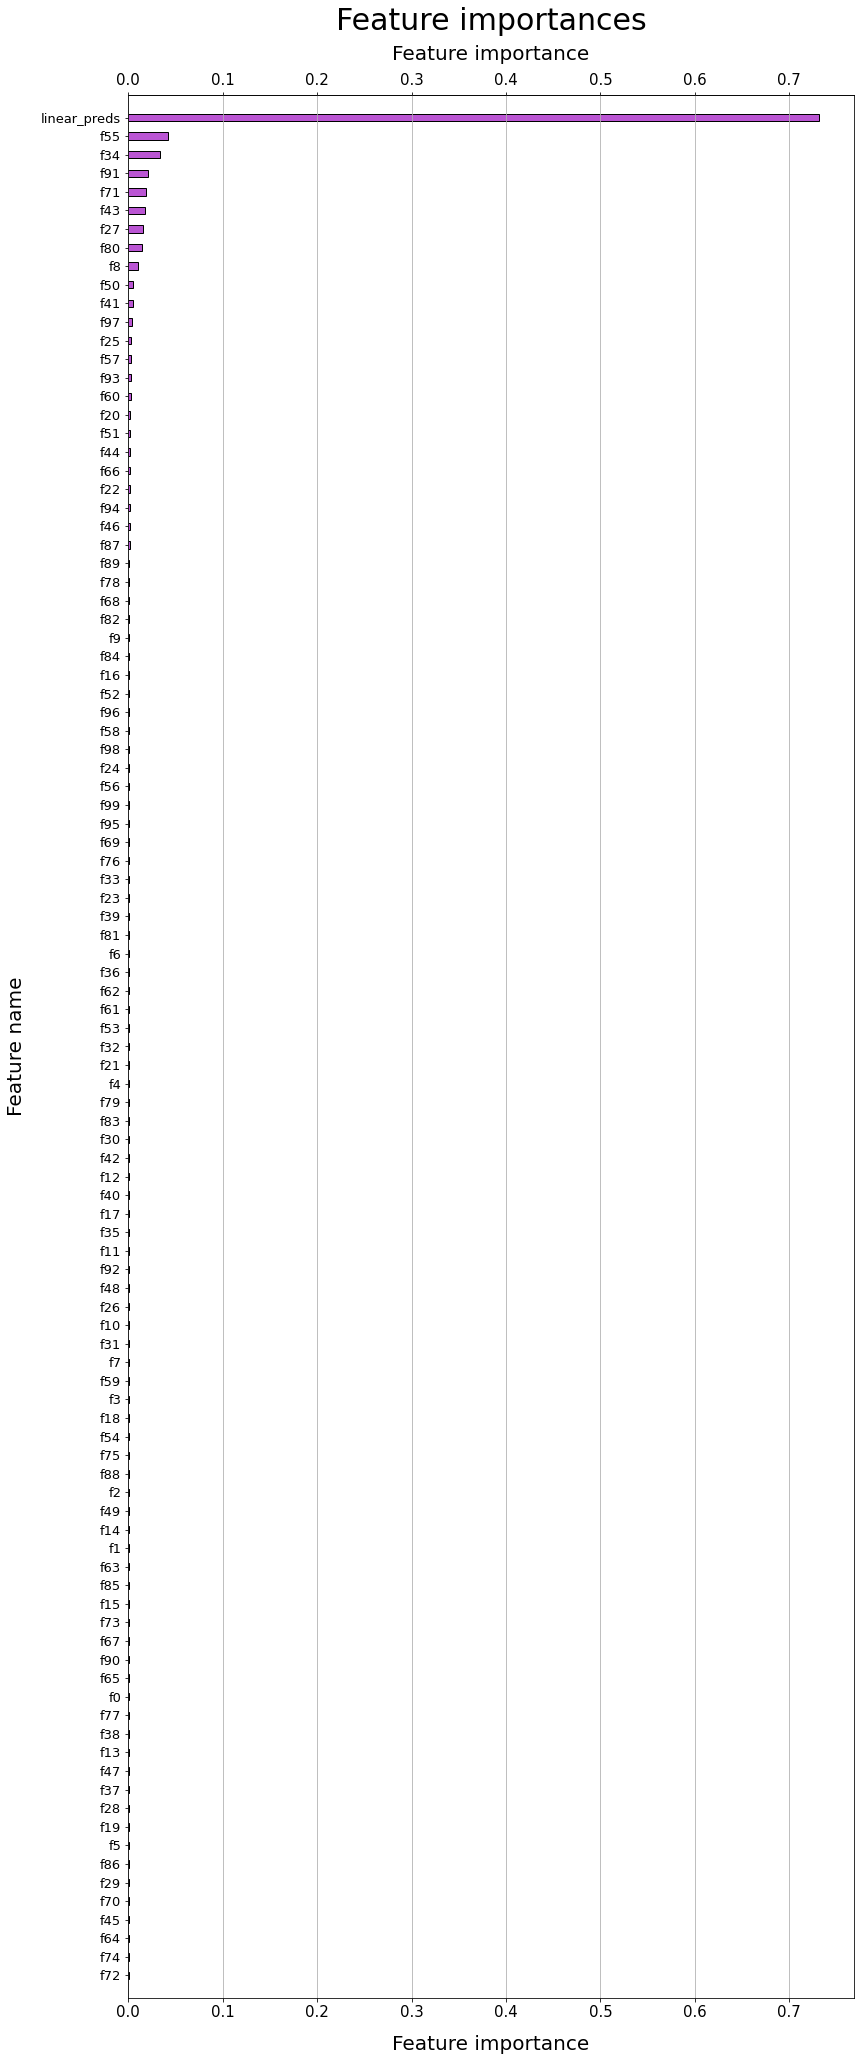

In [23]:
fig, ax = plt.subplots(figsize=(13, 35))
bars = ax.barh(df["Feature"], df["Importance"], height=0.4,
               color="mediumorchid", edgecolor="black")
ax.set_title("Feature importances", fontsize=30, pad=15)
ax.set_ylabel("Feature name", fontsize=20, labelpad=15)
ax.set_xlabel("Feature importance", fontsize=20, labelpad=15)
ax.set_yticks(df["Feature"])
ax.set_yticklabels(df["Feature"], fontsize=13)
ax.tick_params(axis="x", labelsize=15)
ax.grid(axis="x")
# Adding labels on top
ax2 = ax.secondary_xaxis('top')
ax2.set_xlabel("Feature importance", fontsize=20, labelpad=13)
ax2.tick_params(axis="x", labelsize=15)
ax.margins(0.05, 0.01)

# Inverting y axis direction so the values are decreasing
plt.gca().invert_yaxis()

# **Predictions submission**

In [24]:
predictions = pd.DataFrame()
predictions["id"] = test["id"]
predictions["target"] = preds

predictions.to_csv('submission.csv', index=False, header=predictions.columns)
predictions.head()

,id,target
0,600000,0.75958
1,600001,0.70573
2,600002,0.74320
3,600003,0.29300
4,600004,0.70930
